# DECP — Exploration & Feature Engineering
Détection d'anomalies dans les marchés publics français.

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Chargement des données

In [4]:
with open('../data/decp-2022.json', 'r') as f:
    data = json.load(f)

marches = data['marches']
print(f'{len(marches)} marchés chargés')

8756 marchés chargés


In [5]:
def parse_marche(m):
    acheteur = m.get('acheteur', {})
    acheteur_id = acheteur.get('id') if isinstance(acheteur, dict) else None

    titulaires = m.get('titulaires', [])
    tit_ids = []
    if isinstance(titulaires, list):
        for t in titulaires:
            if isinstance(t, dict):
                inner = t.get('titulaire', t)
                tit_ids.append(inner.get('id'))

    return {
        'id': m.get('id'),
        'acheteur_id': acheteur_id,
        'montant': m.get('montant'),
        'dureeMois': m.get('dureeMois'),
        'offresRecues': m.get('offresRecues'),
        'procedure': m.get('procedure'),
        'codeCPV': str(m.get('codeCPV', ''))[:2],
        'nature': m.get('nature'),
        'formePrix': m.get('formePrix'),
        'sousTraitance': m.get('sousTraitanceDeclaree'),
        'marcheInnovant': m.get('marcheInnovant'),
        'nb_titulaires': len(tit_ids),
        'titulaires_ids': tit_ids,
        'dateNotification': m.get('dateNotification'),
    }

df = pd.DataFrame([parse_marche(m) for m in marches])
df['dateNotification'] = pd.to_datetime(df['dateNotification'], errors='coerce')
for col in ['montant', 'dureeMois', 'offresRecues']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
df.shape


(8756, 14)

## 2. Statistiques de base

In [6]:
df[['montant', 'dureeMois', 'offresRecues', 'nb_titulaires']].describe()

,montant,dureeMois,offresRecues,nb_titulaires
count,8.756000e+03,8756.000000,8756.000000,8756.000000
mean,9.705152e+05,21.312357,4.925194,1.148470
std,2.511960e+07,46.464856,143.835999,0.684744
min,0.000000e+00,1.000000,0.000000,0.000000
25%,3.201575e+04,8.000000,2.000000,1.000000
50%,8.960450e+04,14.000000,3.000000,1.000000
75%,2.500000e+05,28.000000,4.000000,1.000000
max,2.024300e+09,4015.000000,13454.000000,13.000000


In [7]:
df['procedure'].value_counts()

procedure
Procédure adaptée                                               6050
Appel d'offres ouvert                                           2280
Marché passé sans publicité ni mise en concurrence préalable     233
Procédure avec négociation                                       138
Appel d'offres restreint                                          27
Procédure négociée ouverte                                        23
Dialogue compétitif                                                4
Procédure non négociée restreinte                                  1
Name: count, dtype: int64

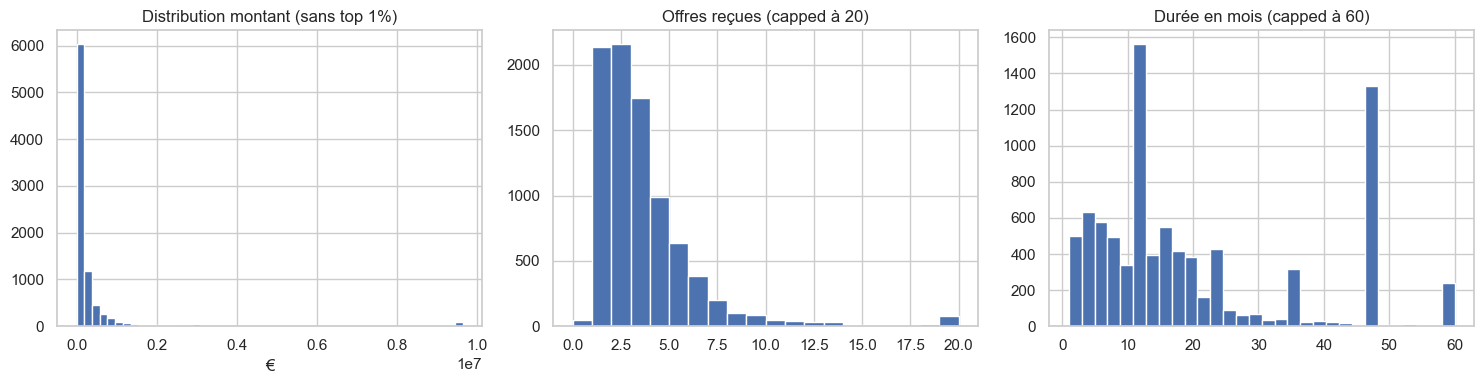

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['montant'].clip(upper=df['montant'].quantile(0.99)).hist(bins=50, ax=axes[0])
axes[0].set_title('Distribution montant (sans top 1%)')
axes[0].set_xlabel('€')

df['offresRecues'].clip(upper=20).hist(bins=20, ax=axes[1])
axes[1].set_title('Offres reçues (capped à 20)')

df['dureeMois'].clip(upper=60).hist(bins=30, ax=axes[2])
axes[2].set_title('Durée en mois (capped à 60)')

plt.tight_layout()
plt.savefig('../plots/distributions.png', dpi=150)
plt.show()

## 3. Feature Engineering

In [9]:
SEUIL_MAPA = 40_000

df_feat = df.copy()

df_feat['montant_log'] = np.log1p(df_feat['montant'].clip(lower=0))
df_feat['offre_unique'] = (df_feat['offresRecues'] == 1).astype(int)
df_feat['sans_concurrence'] = df_feat['procedure'].str.contains(
    'sans publicité|sans mise en concurrence', case=False, na=False
).astype(int)
df_feat['seuil_shaving'] = (
    (df_feat['montant'] >= 35_000) & (df_feat['montant'] < 40_000)
).astype(int)
df_feat['duree_longue'] = (df_feat['dureeMois'] > 48).astype(int)

pair_counts = (
    df_feat[df_feat['nb_titulaires'] == 1]
    .assign(tit_id=df_feat['titulaires_ids'].apply(lambda x: x[0] if x else None))
    .groupby(['acheteur_id', 'tit_id'])
    .size()
    .reset_index(name='nb_contrats_pair')
)
print('Top 5 paires acheteur-titulaire récurrentes:')
print(pair_counts.nlargest(5, 'nb_contrats_pair'))

Top 5 paires acheteur-titulaire récurrentes:
         acheteur_id          tit_id  nb_contrats_pair
3827  31826574100013  78574231300139                27
3031  24840005300059  35286063901494                20
3781  30508017800422  31495270600039                18
4339  44552039800030  33245605200049                18
4340  44552039800030  33861420900017                16


In [10]:
# Encodage de la procédure
procedure_map = {
    'Procédure adaptée': 0,
    'Appel d\'offres ouvert': 1,
    'Marché passé sans publicité ni mise en concurrence préalable': 2,
    'Procédure avec négociation': 3,
    'Appel d\'offres restreint': 4,
    'Procédure négociée ouverte': 5,
    'Dialogue compétitif': 6,
}
df_feat['procedure_code'] = df_feat['procedure'].map(procedure_map).fillna(-1).astype(int)

# Features finales pour le modèle
FEATURES = [
    'montant_log',
    'dureeMois',
    'offresRecues',
    'nb_titulaires',
    'offre_unique',
    'sans_concurrence',
    'seuil_shaving',
    'duree_longue',
    'procedure_code',
]

X = df_feat[FEATURES].fillna(0)
print('Dataset ML prêt:', X.shape)
X.head()

Dataset ML prêt: (8756, 9)


,montant_log,dureeMois,offresRecues,nb_titulaires,offre_unique,sans_concurrence,seuil_shaving,duree_longue,procedure_code
0,10.736418,12.0,1,1,1,0,0,0,0
1,12.443241,8.0,2,1,0,0,0,0,0
2,11.637609,2.0,1,1,1,0,0,0,0
3,10.751050,24.0,1,1,1,0,0,0,3
4,10.991292,22.0,1,1,1,0,0,0,0


## 4. Corrélations entre features

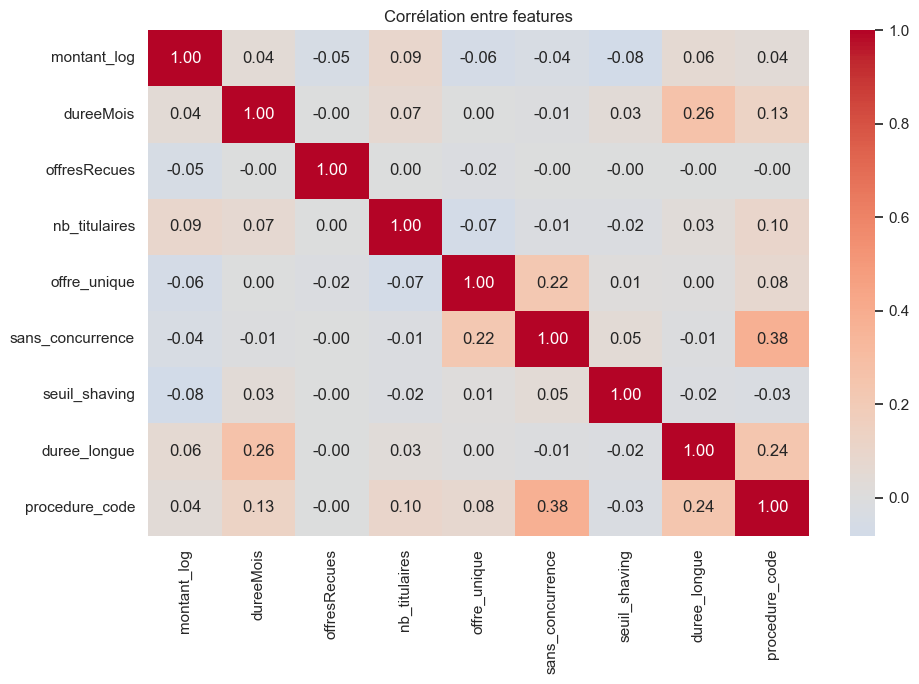

In [11]:
plt.figure(figsize=(10, 7))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Corrélation entre features')
plt.tight_layout()
plt.savefig('../plots/correlations.png', dpi=150)
plt.show()

## 5. Premiers signaux d'anomalie (règles métier)

In [12]:
print('=== Signaux suspects ===')
print(f"Sans concurrence     : {df_feat['sans_concurrence'].sum():>5} marchés ({df_feat['sans_concurrence'].mean()*100:.1f}%)")
print(f"Offre unique         : {df_feat['offre_unique'].sum():>5} marchés ({df_feat['offre_unique'].mean()*100:.1f}%)")
print(f"Seuil shaving (~40k) : {df_feat['seuil_shaving'].sum():>5} marchés ({df_feat['seuil_shaving'].mean()*100:.1f}%)")
print(f"Durée > 48 mois      : {df_feat['duree_longue'].sum():>5} marchés ({df_feat['duree_longue'].mean()*100:.1f}%)")
print()

# Cumul des signaux
df_feat['nb_signaux'] = (
    df_feat['sans_concurrence'] +
    df_feat['offre_unique'] +
    df_feat['seuil_shaving'] +
    df_feat['duree_longue']
)
print('Distribution du nombre de signaux par marché:')
print(df_feat['nb_signaux'].value_counts().sort_index())

=== Signaux suspects ===
Sans concurrence     :   233 marchés (2.7%)
Offre unique         :  2137 marchés (24.4%)
Seuil shaving (~40k) :   265 marchés (3.0%)
Durée > 48 mois      :   280 marchés (3.2%)

Distribution du nombre de signaux par marché:
nb_signaux
0    6181
1    2255
2     301
3      18
4       1
Name: count, dtype: int64


In [13]:
# Top marchés les plus suspects (règles métier)
colonnes_affichage = ['id', 'montant', 'procedure', 'offresRecues', 'dureeMois', 'nb_signaux']
df_feat.nlargest(10, 'nb_signaux')[colonnes_affichage]

,id,montant,procedure,offresRecues,dureeMois,nb_signaux
2524,2024074,39745.0,Marché passé sans publicité ni mise en concurr...,1,60.0,4
337,24-1040910,39030.0,Procédure adaptée,1,60.0,3
1188,24-1023889,39999.0,Marché passé sans publicité ni mise en concurr...,1,48.0,3
2273,240461,39738.0,Marché passé sans publicité ni mise en concurr...,1,12.0,3
2821,202323TKM06009,37898.0,Marché passé sans publicité ni mise en concurr...,1,20.0,3
3304,241017191,39000.0,Marché passé sans publicité ni mise en concurr...,1,12.0,3
3626,24-1029636,5200000.0,Marché passé sans publicité ni mise en concurr...,1,86.0,3
3801,24-993266,35130.0,Marché passé sans publicité ni mise en concurr...,1,5.0,3
3973,24-0661,12750.0,Marché passé sans publicité ni mise en concurr...,1,60.0,3
4160,24-003,37854.0,Marché passé sans publicité ni mise en concurr...,1,8.0,3


In [14]:
# Sauvegarder le dataset avec features
import os
os.makedirs('../data', exist_ok=True)
df_feat.to_parquet('../data/decp_2022_features.parquet', index=False)
print('Sauvegardé dans data/decp_2022_features.parquet')

Sauvegardé dans data/decp_2022_features.parquet
